# Strategy Performance

*Andrew Wang · 2026-08-08*

## Contents

1. [Introduction](#introduction)
2. [Baseline Strategies](#baseline-strategies)
3. [PnL and Risk](#pnl-and-risk)
4. [Head-to-Head Comparison](#head-to-head-comparison)
5. [Conclusion](#conclusion)

## Introduction

It is important and interesting to think about how we can measure the performance of different strategies. The obvious thing would be the end PnL, and perhaps averaged over many seeds. However, we also want to visualize how _quickly_ the strategy learns. In other words, it is not enough to measure which strategies acumulates most PnL in the end, but how fast they do this. Moreover, merely measuring the PnL differences will not be very enlightening as will be shown later, and will not be a very effective performance differentiator. So, we introduce the quantity of regret. We define the regret as a function that takes in the true popping probability $p$, true popping value $v$ and a strategy's PnL gain from a single balloon $g$:
$
\begin{equation}
    regret(p, g) = r(p, g) = \mathbb{1} \left \{ \left \lceil \frac{1-p}{p} \right \rceil < v \right \} \times \left \lceil \frac{1-p}{p} \right \rceil - g
\end{equation}
$

Or in other words, the regret of a strategy is the difference between the PnL gain of an oracle strategy that knows the true popping probabilities and its own PnL gain. The quantity we really care about is the cumulative regret, the definition of which is self-explanatory. Importantly though, we can notice now that despite knowing the true probabilities, a strastegy still might just get _unlucky_. This introduces a source of noise in our data. To remove this, we can compute the _expected_ regret or also sometimes called _pseudo_regret. The definition of which is:

$
\begin{equation}
    r_e(p, g, k) = \mathbb{E}[r(p, g)] = \left \lceil \frac{1-p}{p} \right \rceil (1-p)^{\left \lceil \frac{1-p}{p} \right \rceil} - k(1-p)^{k}
\end{equation}
$
where $k$ is the threshold that the strategy proposes. 

Another metric that we should measure is the following. It is clear that a good strategy should over the long run converge to the _correct_ threshold, i.e 
$\begin{equation}
\left \lceil \frac{1-p}{p} \right \rceil 
\end{equation}
$
So, it might be a good metric to measure the difference between a strategy's threshold and the correct threshold. We can call this quantity $d$:
$\begin{equation}
d(k, p) = \left(k-\left \lceil \frac{1-p}{p} \right \rceil \right)^2
\end{equation}
$
where $k$ is still the same $k$ (the strategy's threshold). Computation of these metrics can be found in _metrics.py_ in the modules folder.

## Baseline Strategies

The most basic strategy one can think of is to "just guess". In other words, at each balloon, pick a random number of pumps between 1 and $n$. There is no particular canonical choice for $n$, theire performances would merely depend on how the true probabilities are distributed. Another obvious strategy is to assume that the average type of balloon has a $50%$ popping probability, and would therefore in expectation pop after $2$ pumps. In this case, always pumping once would be the strategy. We can plot their performances:

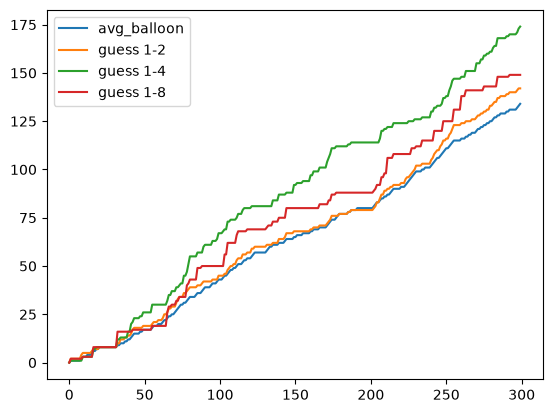

In [12]:
from matplotlib import pyplot as plt
import pandas as pd
import os
import sys
MODULES_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "modules"))
if MODULES_DIR not in sys.path:
    sys.path.insert(0, MODULES_DIR)

from paths import GAME_LOG_PATH

df_avg = pd.read_csv(os.path.join(GAME_LOG_PATH, "game_111_average_balloon_log.csv"))
df_guess_3 = pd.read_csv(os.path.join(GAME_LOG_PATH, "game_111_guess_3_log.csv"))
df_guess_5 = pd.read_csv(os.path.join(GAME_LOG_PATH, "game_111_guess_5_log.csv"))
df_guess_9 = pd.read_csv(os.path.join(GAME_LOG_PATH, "game_111_guess_9_log.csv"))

x = df_avg["balloon_id"]
y_avg = df_avg["end_PnL"]
y_guess_3 = df_guess_3["end_PnL"]
y_guess_5 = df_guess_5["end_PnL"]
y_guess_9 = df_guess_9["end_PnL"]

plt.plot(x, y_avg, label= "avg_balloon")
plt.plot(x, y_guess_3, label= "guess 1-2")
plt.plot(x, y_guess_5, label= "guess 1-4")
plt.plot(x, y_guess_9, label= "guess 1-8")
plt.legend()
plt.show()

From this graph alone, it would seem like all of these strategies are performing similarly, with perhaps the blue one being slightly worse than the others and the green being slightly better. However, if we plot the realized cumulative regret, we obtain the following plot:

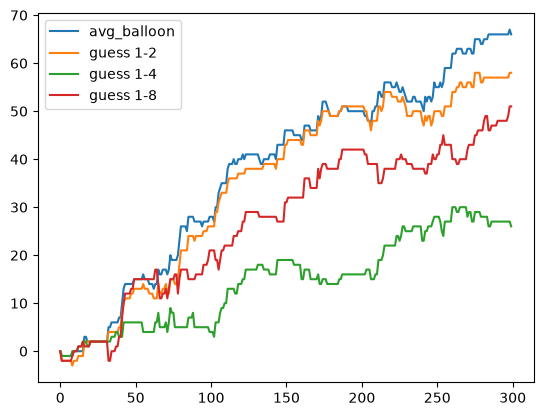

In [13]:
import json
from metrics import add_regret
def read_manifest(filename: str) -> dict:
    with open(os.path.join(GAME_LOG_PATH, filename), "r") as f:
        manifest = json.load(f)   # data is now a dict (if the top-level JSON is an object)
    return manifest


manifest_avg = read_manifest(os.path.join(GAME_LOG_PATH, "game_111_average_balloon_meta.json"))
manifest_guess_3 = read_manifest(os.path.join(GAME_LOG_PATH, "game_111_guess_3_meta.json"))
manifest_guess_5 = read_manifest(os.path.join(GAME_LOG_PATH, "game_111_guess_5_meta.json"))
manifest_guess_9 = read_manifest(os.path.join(GAME_LOG_PATH, "game_111_guess_9_meta.json"))

x = df_avg["balloon_id"]
y_avg = add_regret(df_avg, manifest_avg)["regret"]
y_guess_3 = add_regret(df_guess_3, manifest_guess_3)["regret"]
y_guess_5 = add_regret(df_guess_5, manifest_guess_5)["regret"]
y_guess_9 = add_regret(df_guess_9, manifest_guess_9)["regret"]

plt.plot(x, y_avg, label= "avg_balloon")
plt.plot(x, y_guess_3, label= "guess 1-2")
plt.plot(x, y_guess_5, label= "guess 1-4")
plt.plot(x, y_guess_9, label= "guess 1-8")
plt.legend()
plt.show()

Since we want to minimize regret, we can now much more clearly see that the green strategy is doing a lot better than the others, especially midgame. Of course, this could very likely be an artifact of this specific game seed, and the natural step is then to average over many seeds.

## PnL and Risk

## Head-to-Head Comparison

## Conclusion